In [1]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

from rdkit import Chem

def get_rotatable_bonds(mol, strict=True):
    """
    Identifies rotatable bonds in a molecule based on RDKit's strict 
    and non-strict SMARTS patterns.

    Returns:
        A tuple containing two lists of tuples: (strict_bonds, non_strict_bonds)
    """

    if strict:
        # SMARTS pattern for strict rotatable bonds (Lipinski definition)
        # This excludes amides, esters, and bonds to certain groups.
        strict_smarts = '[!$(*#*)&!D1&!$(C(F)(F)F)&!$(C(Cl)(Cl)Cl)&!$(C(Br)(Br)Br)&!$(C([CH3])([CH3])[CH3])&!$([CD3](=[N,O,S])-!@[#7,O,S!D1])&!$([#7,O,S!D1]-!@[CD3]=[N,O,S])&!$([CD3](=[N+])-!@[#7!D1])&!$([#7!D1]-!@[CD3]=[N+])]-&!@[!$(*#*)&!D1&!$(C(F)(F)F)&!$(C(Cl)(Cl)Cl)&!$(C(Br)(Br)Br)&!$(C([CH3])([CH3])[CH3])]'
        strict_query = Chem.MolFromSmarts(strict_smarts)
        strict_bonds = mol.GetSubstructMatches(strict_query)
        return strict_bonds
    else:
        # SMARTS pattern for non-strict rotatable bonds
        # This is a broader definition.
        non_strict_smarts = '[!$(*#*)&!D1]-&!@[!$(*#*)&!D1]'
        non_strict_query = Chem.MolFromSmarts(non_strict_smarts)
        non_strict_bonds = mol.GetSubstructMatches(non_strict_query)
        return non_strict_bonds

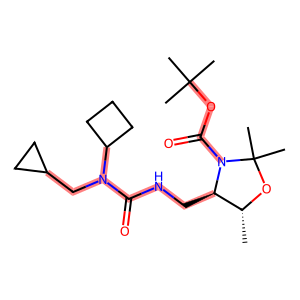

In [2]:
# Get the rotatable bonds
mol = Chem.MolFromSmiles('C[C@H]1OC(C)(C)N(C(=O)OC(C)(C)C)[C@@H]1CNC(=O)N(CC1CC1)C1CCC1') 
rotatable_bonds = get_rotatable_bonds(mol, strict=False)

# Create a molecule copy for drawing
mol_copy = Chem.Mol(mol)

# Set bond highlights
bond_colors = {}
for bond_pair in rotatable_bonds:
    bond = mol_copy.GetBondBetweenAtoms(bond_pair[0], bond_pair[1])
    bond_colors[bond.GetIdx()] = (1, 0, 0)  # Red color for rotatable bonds

# Draw the molecule with highlighted bonds
from rdkit.Chem import Draw
Draw.MolToImage(mol_copy, highlightBonds=list(bond_colors.keys()), highlightBondColors=list(bond_colors.values()))

In [3]:
# Print atom indices for each rotatable bond
print("Rotatable bond atom indices:")
for bond_pair in rotatable_bonds:
    print(f"Atoms {bond_pair[0]} and {bond_pair[1]} form a rotatable bond")

Rotatable bond atom indices:
Atoms 6 and 7 form a rotatable bond
Atoms 7 and 9 form a rotatable bond
Atoms 9 and 10 form a rotatable bond
Atoms 14 and 15 form a rotatable bond
Atoms 15 and 16 form a rotatable bond
Atoms 16 and 17 form a rotatable bond
Atoms 17 and 19 form a rotatable bond
Atoms 19 and 20 form a rotatable bond
Atoms 19 and 24 form a rotatable bond
Atoms 20 and 21 form a rotatable bond


In [4]:
def find_connected_rotatable_bond_ends(mol):
    """Find the ends of connected sequences of rotatable bonds.
    
    Args:
        mol: RDKit molecule object
        rotatable_bonds: List of tuples containing atom indices of rotatable bonds
        
    Returns:
        List of tuples containing atom indices of the ends of connected rotatable bond sequences
    """
    # Count occurrences of each atom in rotatable bonds
    rotatable_bonds = get_rotatable_bonds(mol, strict=False)

    atom_counts = {}
    for bond in rotatable_bonds:
        for atom in bond:
            atom_counts[atom] = atom_counts.get(atom, 0) + 1
            
    # Find atoms that appear only once - these are the ends
    end_atoms = [atom for atom, count in atom_counts.items() if count == 1]
    
    # Find bonds that contain these end atoms
    end_bonds = []
    for bond in rotatable_bonds:
        if bond[0] in end_atoms or bond[1] in end_atoms:
            end_bonds.append(bond)

    return end_bonds

# Test the function
connected_ends = find_connected_rotatable_bond_ends(mol)
print("\nRotatable bonds containing end atoms:")
for bond in connected_ends:
    print(f"Bond between atoms {bond[0]} and {bond[1]}")


Rotatable bonds containing end atoms:
Bond between atoms 6 and 7
Bond between atoms 9 and 10
Bond between atoms 14 and 15
Bond between atoms 19 and 24
Bond between atoms 20 and 21


In [5]:
connected_ends

[(6, 7), (9, 10), (14, 15), (19, 24), (20, 21)]

In [6]:
from argo.frag_utils import SAFECodec

/nas/longleaf/home/shuhang/miniconda3/envs/f-rag/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
rot_bond_slicer = SAFECodec(slicer=find_connected_rotatable_bond_ends)
frag_slicer = SAFECodec(slicer='f-rag')

In [8]:
#smiles = 'O=C([O-])c1cc2c(cc1C(=O)[O-])C(NS(=O)(=O)c1ccc(C3CCCCC3)cc1)CC2'
smiles = 'Cc1ccc(-n2cc(C(=O)N[C@H]3C[C@@H](Cc4nn[n-]n4)C3)c(C(C)(C)C)n2)cc1'
#smiles = 'O=C([O-])c1cc(C(=O)[O-])cc(C(=O)N2Cc3ccccc3-c3ccccc32)c1'

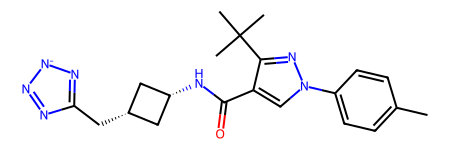

In [9]:
Chem.MolFromSmiles(smiles)

In [10]:
safe_str = rot_bond_slicer.encode(smiles)
print(safe_str)

Cc1ccc5cc1.n15cc6c%10n1.[C@H]17C[C@@H]8C1.c19nn[n-]n1.C6(=O)N7.C%10(C)(C)C.C89


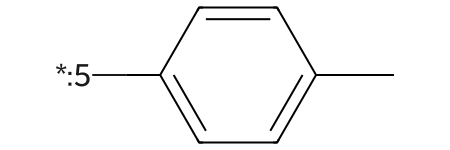

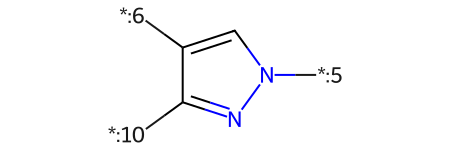

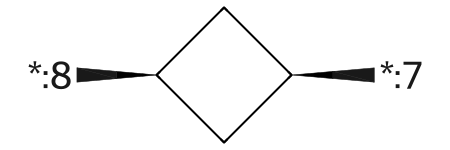

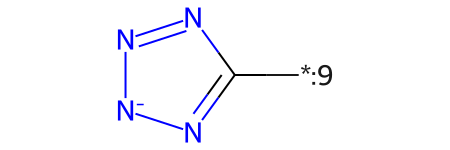

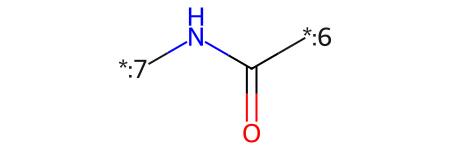

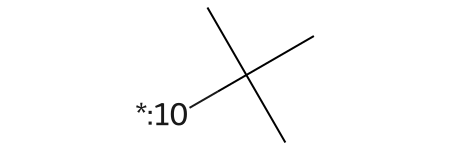

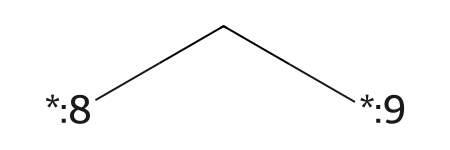

In [11]:
# Split the SAFE string into fragments
fragments = safe_str.split('.')

# Draw each fragment
for i, frag in enumerate(fragments):
    mol = Chem.MolFromSmiles(rot_bond_slicer.decode(frag))
    display(mol)

In [12]:
safe_str = frag_slicer.encode(smiles)
print(safe_str)

Cc1ccc(-n2cc5c(C(C)(C)C)n2)cc1.[C@H]16C[C@@H](Cc2nn[n-]n2)C1.C5(=O)N6


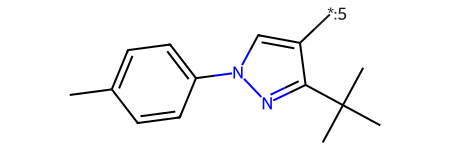

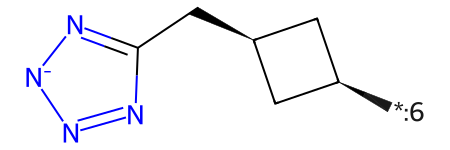

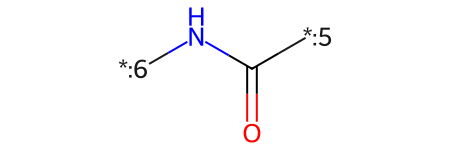

In [13]:
# Split the SAFE string into fragments
fragments = safe_str.split('.')

# Draw each fragment
for i, frag in enumerate(fragments):
    mol = Chem.MolFromSmiles(rot_bond_slicer.decode(frag))
    display(mol)

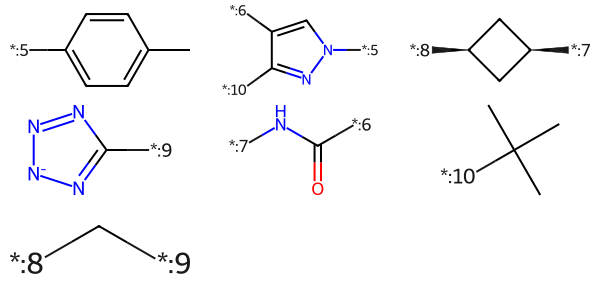

In [17]:
def draw_fragments(slicer, smiles, n_cols=3, img_size=(200,100)):
    """
    Draw all fragments from a sliced molecule in a grid layout
    
    Args:
        slicer: The fragmenter object (rot_bond_slicer or frag_slicer)
        smiles: SMILES string of the molecule to fragment
        n_cols: Number of columns in the grid layout
        img_size: Size of each fragment image (width, height)
    
    Returns:
        PIL Image containing all fragments in a grid
    """
    from PIL import Image
    import math
    
    # Get fragments
    safe_str = slicer.encode(smiles)
    fragments = safe_str.split('.')
    
    # Calculate grid dimensions
    n_frags = len(fragments)
    n_rows = math.ceil(n_frags / n_cols)
    
    # Create blank image
    total_width = n_cols * img_size[0]
    total_height = n_rows * img_size[1]
    combined_img = Image.new('RGB', (total_width, total_height), 'white')
    
    # Add each fragment
    for i, frag in enumerate(fragments):
        mol = Chem.MolFromSmiles(rot_bond_slicer.decode(frag))
        img = Draw.MolToImage(mol, size=img_size)
        
        # Calculate position
        row = i // n_cols
        col = i % n_cols
        x = col * img_size[0]
        y = row * img_size[1]
        
        combined_img.paste(img, (x,y))
        
    return combined_img

# Test the function
img = draw_fragments(rot_bond_slicer, smiles)
display(img)

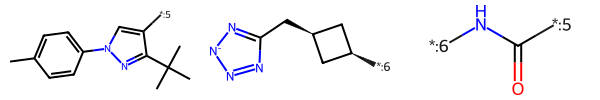

In [18]:
draw_fragments(frag_slicer, smiles)